# Kicker Strategy - Results

In [152]:
import pandas as pd
import numpy as np
import json
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.proportion import proportions_ztest
import scipy.stats as stats

In this notebook, we tested various hypotheses regarding player traits and general patterns that derived from our EDA in the experiments.ipynb notebook. 

We used the following statistical tests:
- **Welch's t-test:** for hypotheses with continuous variables (e.g. hold time of one player vs. the others)
- **Z-test for proportions:** for hypotheses which compare two percentage rates or probabilities (e.g. conversion rate when winning vs. losing)
- **Pearson correlation test:** for hypotheses which contain the correlation between two variables (e.g. correlation of attack bias with number of goals)

We didn't test for test assumptions/requirements.

We used an alpha of 0.05 and adjusted it with the Bonferroni correction to account for alpha inflation due to multiple testing. Given that we tested 25 main hypotheses (two of which contain two sub-hypotheses, resulting in a total of 27 statistical tests), our adjusted significance threshold is:
$$\alpha_{adj} = \frac{0.05}{27} \approx 0.00185$$

A result is considered statistically significant if its p-value is below this threshold.

### Data Import

The following code cell extracts the event data from the provided json files into a pandas dataframe and creates new features (e.g. possession_length, prev_side) that we needed for our hypotheses.

In [ ]:
results = glob.glob("results/*.json")
file_list = []

for files in results:
    # Open files
    with open(files, "r") as file:
        data = json.load(file)

    events_list = []
    # Assign filename to "game" column
    game = os.path.basename(files).replace(".json", "")

    # Loop through the runs
    for run in data.get("runs", []):
        run_id = run["run_id"]
        player_1 = run["player_1"]
        player_2 = run["player_2"]
        # Loop through events
        for event in run.get("events", []):
            events_list.append({
                "game": game,
                "run_id": run_id,
                "player_1": player_1,
                "player_2": player_2,
                "timestamp": event["timestamp"],
                "player": event["player"],
                "event_type": event["type"],
                "bar": event.get("bar", pd.NA),
                "side": event.get("side", pd.NA),
                "is_goal": event.get("successful", False) #True if successful, False if not successful
            })

    # Convert to dataframe
    df_game = pd.DataFrame(events_list)
    file_list.append(df_game)

timestamped_data = pd.concat(file_list, ignore_index=True)
timestamped_data = timestamped_data.sort_values(by=["game", "run_id", "timestamp"]).reset_index(drop=True)
timestamped_data["is_shot"] = timestamped_data["event_type"] == "shot"

timestamped_data['round'] = timestamped_data.groupby(['game', 'run_id'])['is_goal'].shift(fill_value=False).cumsum() + 1 #counts up whenever the previous row was a goal (shift function moves it down 1 row)
timestamped_data['is_contact_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 1 contact
timestamped_data['is_contact_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'contact') #boolean column whether it was a player 2 contact
timestamped_data['is_shot_p1'] = (timestamped_data['player'] == timestamped_data['player_1']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 1 shot
timestamped_data['is_shot_p2'] = (timestamped_data['player'] == timestamped_data['player_2']) & (timestamped_data['event_type'] == 'shot') #boolean column whether it was a player 2 shot

timestamped_data['prev_player'] = timestamped_data.groupby(['game', 'run_id'])['player'].shift(1) #shift(1) -> taking the row above
timestamped_data['prev_bar'] = timestamped_data.groupby(['game', 'run_id'])['bar'].shift(1)
timestamped_data['prev_side'] = timestamped_data.groupby(['game', 'run_id'])['side'].shift(1)
timestamped_data['prev_event'] = timestamped_data.groupby(['game', 'run_id'])['event_type'].shift(1)
timestamped_data['prev_timestamp'] = timestamped_data.groupby(['game', 'run_id'])['timestamp'].shift(1)

#normalizing the prev_side column for player 2 for side hypotheses
timestamped_data['prev_side_normalized'] = timestamped_data['prev_side']
is_p2 = timestamped_data['prev_player'] == timestamped_data['player_2']
timestamped_data.loc[is_p2, 'prev_side_normalized'] = timestamped_data.loc[is_p2, 'prev_side'].map({'Left': 'Right', 'Right': 'Left'}).fillna(timestamped_data['prev_side'])

timestamped_data['possession_change'] = timestamped_data['player'] != timestamped_data['player'].shift() #boolean column whether the player in the current row is different from the player in the previous row -> indicates a change of possession
timestamped_data['possession_id'] = timestamped_data['possession_change'].cumsum()
timestamped_data['possession_length'] = timestamped_data.groupby('possession_id').cumcount() + 1

shots = timestamped_data[timestamped_data["event_type"] == "shot"].copy()
shots["hold_time"] = shots["timestamp"] - timestamped_data.groupby(["game", "run_id"])["timestamp"].shift(1)
shots = shots[(shots["hold_time"] > 0) & (shots["hold_time"].notna())]
shots["prev_bar_clean"] = shots["prev_bar"].str.replace(r"\d+", "", regex=True).str.strip()

shots["p1_scored"] = ((shots["player"] == shots["player_1"]) & (shots["is_goal"] == True)).astype(int)
shots["p2_scored"] = ((shots["player"] == shots["player_2"]) & (shots["is_goal"] == True)).astype(int)
shots["points_p1"] = shots.groupby(["game", "run_id"])["p1_scored"].cumsum().shift(1).fillna(0)
shots["points_p2"] = shots.groupby(["game", "run_id"])["p2_scored"].cumsum().shift(1).fillna(0)

shots["cum_points_p1"] = shots.groupby(["game", "run_id"])["p1_scored"].cumsum().shift(1).fillna(0)
shots["cum_points_p2"] = shots.groupby(["game", "run_id"])["p2_scored"].cumsum().shift(1).fillna(0)

shots["score_diff_for_player"] = np.where(
    shots["player"] == shots["player_1"],
    shots["cum_points_p1"] - shots["cum_points_p2"],
    shots["cum_points_p2"] - shots["cum_points_p1"])

def point_situation(diff):
    if diff > 0:
        return "more points"
    elif diff < 0:
        return "fewer points"
    else:
        return "tie"

shots["situation"] = shots["score_diff_for_player"].apply(point_situation) #categorizing the point difference into "more points", "fewer points" or "tie" for the player who took the shot

#aggregating the data for each round
round_data = timestamped_data.groupby(['game', 'run_id', 'round']).agg( #aggregating the data for each round
    start=('timestamp', 'min'), #minimum timestamp in all of the rows for a round -> minimum -> first row
    end=('timestamp', 'max'), #maximum timestamp in all of the rows for a round -> maximum -> last row
    player_1=('player_1', 'first'), #just takes the value of the first row of a round -> doesn't matter because it's the same in all of the rows
    player_2=('player_2', 'first'), 
    contacts_p1=('is_contact_p1', 'sum'), #sum of all the contacts for player 1 (count of True in the boolean column see above)
    contacts_p2=('is_contact_p2', 'sum'), 
    shots_p1=('is_shot_p1', 'sum'),
    shots_p2=('is_shot_p2', 'sum')
).reset_index()

round_data.columns = ['game', 'run_id', 'round', 'start', 'end', 'player_1', 'player_2', 'contacts_p1', 'contacts_p2', 'shots_p1', 'shots_p2']

winners = timestamped_data[timestamped_data['is_goal']].set_index(['game', 'run_id', 'round'])['player'] #filters the goal rows and then extracts the player who shot the goal (=winner) for each round
round_data = round_data.join(winners, on=['game', 'run_id', 'round']).rename(columns={'player': 'round_winner'}) #joins the winner on game, run_id and round

round_data['duration'] = round_data['end'] - round_data['start'] #calculating duration
round_data['p1_won_round'] = (round_data['round_winner'] == round_data['player_1']) #boolean column whether player 1 won the round
round_data['p2_won_round'] = (round_data['round_winner'] == round_data['player_2']) #boolean columns whether player 2 won the round

round_data['points_p1'] = round_data.groupby(['game', 'run_id'])['p1_won_round'].transform('cumsum') #counts up if player 1 won
round_data['points_p2'] = round_data.groupby(['game', 'run_id'])['p2_won_round'].transform('cumsum') #counts up if player 2 won

round_data.drop(columns=['game','p1_won_round', 'p2_won_round'], inplace=True) #dropping unneccessary columns

### Data Overview

This is now the dataframe that we used for most of our hypotheses:

In [154]:
timestamped_data.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,...,is_shot_p2,prev_player,prev_bar,prev_side,prev_event,prev_timestamp,prev_side_normalized,possession_change,possession_id,possession_length
0,Diana-Hans,0,Diana,Hans,2.985530,Diana,contact,Middle1,Middle,False,...,False,NaN,NaN,NaN,NaN,NaN,NaN,True,1,1
1,Diana-Hans,0,Diana,Hans,3.749828,Diana,contact,Attack1,Right,False,...,False,Diana,Middle1,Middle,contact,2.985530,Middle,False,1,2
2,Diana-Hans,0,Diana,Hans,6.102422,Hans,contact,Attack2,Middle,False,...,False,Diana,Attack1,Right,contact,3.749828,Right,True,2,1
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,...,True,Hans,Attack2,Middle,contact,6.102422,Middle,False,2,2
4,Diana-Hans,0,Diana,Hans,20.291921,Diana,contact,Middle1,Middle,False,...,False,Hans,NaN,NaN,shot,10.453081,NaN,True,3,1


The following dataframe we used for all hypotheses regarding shots:

In [155]:
shots.head()

,game,run_id,player_1,player_2,timestamp,player,event_type,bar,side,is_goal,...,hold_time,prev_bar_clean,p1_scored,p2_scored,points_p1,points_p2,cum_points_p1,cum_points_p2,score_diff_for_player,situation
3,Diana-Hans,0,Diana,Hans,10.453081,Hans,shot,NaN,NaN,True,...,4.350659,Attack,0,1,0.0,0.0,0.0,0.0,0.0,tie
6,Diana-Hans,0,Diana,Hans,23.388610,Diana,shot,NaN,NaN,False,...,1.949856,Defense,0,0,0.0,1.0,0.0,1.0,-1.0,fewer points
9,Diana-Hans,0,Diana,Hans,33.182286,Hans,shot,NaN,NaN,False,...,6.022342,Attack,0,0,0.0,1.0,0.0,1.0,1.0,more points
11,Diana-Hans,0,Diana,Hans,35.235728,Diana,shot,NaN,NaN,False,...,2.053442,Defense,0,0,0.0,1.0,0.0,1.0,-1.0,fewer points
16,Diana-Hans,0,Diana,Hans,50.007118,Hans,shot,NaN,NaN,False,...,6.408872,Goal,0,0,0.0,1.0,0.0,1.0,1.0,more points


And this is the dataframe for hypotheses regarding rounds (events between two goals):

In [156]:
round_data.head()

,run_id,round,start,end,player_1,player_2,contacts_p1,contacts_p2,shots_p1,shots_p2,round_winner,duration,points_p1,points_p2
0,0,1,2.985530,10.453081,Diana,Hans,2,1,0,1,Hans,7.467551,0,1
1,0,2,20.291921,51.365341,Diana,Hans,5,5,3,2,Diana,31.073420,1,1
2,0,3,56.560030,150.898025,Diana,Hans,15,17,5,7,Diana,94.337994,2,1
3,0,4,164.168779,178.463446,Diana,Hans,3,2,3,1,Diana,14.294667,3,1
4,0,5,191.487753,208.643816,Diana,Hans,4,5,3,2,Hans,17.156064,3,2


# 4. Core Results

We structured our results in the general order of a round until a goal: first everything regarding ball control and pacing dynamics, then passing and shot strategies, then the shot execution and finally the defense of the opponent.

## 4.1 Ball Control and Pacing Dynamics

### 4.1.1 Plots and Results

##### Hold Time

First, we looked into the hold time which is the time between the previous contact before a shot and the execution of the shot.

In [157]:
player_hold_time = (shots.groupby("player")["hold_time"].mean().reset_index().rename(columns={"hold_time": "avg_hold_time"}))
player_hold_time.sort_values(by="avg_hold_time", ascending=True)

,player,avg_hold_time
0,Diana,1.808285
2,Magnus,2.084011
3,Olga,2.579928
4,Simon,2.923587
5,Tanja,2.950816
1,Hans,4.200696


We can see that Diana has the lowest average hold time and Hans has the highest average hold time.

#### Tanja Hold Time

For one hypothesis, we looked into Tanja's hold time when winning (she has more points than the opponent) vs. when losing (she has fewer points than the opponent). For that, we created a dataframe with her shots and created a new column "score_state".

In [158]:
tanja_shots = shots[shots["player"] == "Tanja"].copy()
is_p1 = (tanja_shots["player_1"] == "Tanja")

tanja_shots["is_winning"] = np.where(is_p1, tanja_shots["points_p1"] > tanja_shots["points_p2"], tanja_shots["points_p2"] > tanja_shots["points_p1"])
tanja_shots["is_losing"] = np.where(is_p1, tanja_shots["points_p1"] < tanja_shots["points_p2"], tanja_shots["points_p2"] < tanja_shots["points_p1"])
tanja_shots["score_state"] = np.select([tanja_shots["is_winning"], tanja_shots["is_losing"]], ["Winning", "Losing"], default="Tied")

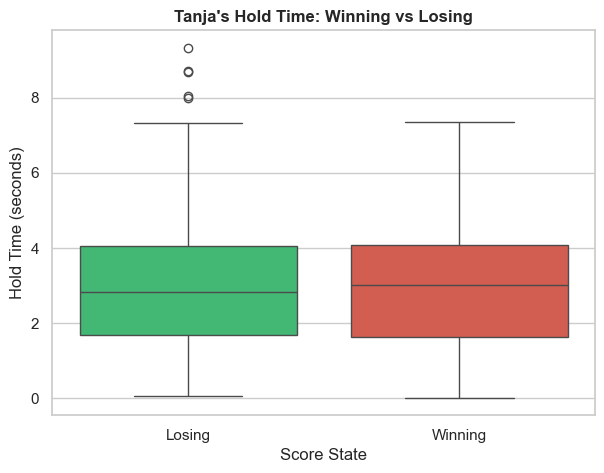

In [159]:
# Plot for Tanja's Hold time
plt.figure(figsize=(7, 5))
sns.boxplot(data=tanja_shots[tanja_shots["score_state"].isin(["Winning", "Losing"])], x="score_state", y="hold_time", hue="score_state",
            palette=["#2ecc71", "#e74c3c"])
plt.title("Tanja's Hold Time: Winning vs Losing", fontweight="bold")
plt.ylabel("Hold Time (seconds)")
plt.xlabel("Score State")
plt.show()

Her hold time seems to be slightly higher when she is winning but the difference is not very high.

#### Posession Length

We also looked into the possession length which is the number of consecutive events of ball possession. The following table shows the average possession length for each player when taking a shot. This represents the amount of passing each player does before shooting at the goal.

In [160]:
player_posession_length = (shots.groupby("player")["possession_length"].mean().reset_index().rename(columns={"possession_length": "avg_posession_length"}))
player_posession_length.sort_values(by="avg_posession_length", ascending=True)

,player,avg_posession_length
1,Hans,2.823477
5,Tanja,3.105461
0,Diana,3.165929
2,Magnus,3.281563
4,Simon,3.384787
3,Olga,4.067771


Hans has the lowest average possession length when shooting a goal whereas Olga has the highest average possession length.

### 4.1.2 Hypotheses

#### Hypothesis 1: Hans holds the ball longer before taking a shot compared to the other players

H0: There is no statistically significant difference between Hans's hold time and the hold time of the other players.

H1: Hans has a statistically significant higher hold time compared to the other players.

We're using a right-tailed Welch's t-test to compare the mean hold times.

We define $\mu_{\text{Hans}}$ as the mean hold time of Hans and $\mu_{\text{Others}}$ as the aggregated mean hold time of the other players.

$$H_0: \mu_{\text{Hans}} \le \mu_{\text{Others}}$$
$$H_1: \mu_{\text{Hans}} > \mu_{\text{Others}}$$

In [161]:
hans_hold_times = shots.loc[shots["player"] == "Hans", "hold_time"]
others_hold_times = shots.loc[shots["player"] != "Hans", "hold_time"]

t_stat, p_value = stats.ttest_ind(hans_hold_times, others_hold_times, equal_var=False, alternative="greater")

print(f"p value: {p_value:.4e}")

p value: 1.0118e-91


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis. This means that Hans shows a significantly lower hold time than the other players.

#### Hypothesis 2: Diana holds the ball shorter before taking a shot compared to the other Players

H0: There is no statistically significant difference between Diana's hold time and the hold time of the other players.

H1: Diana has a statistically significant shorter hold time compared to the other players.

We're using a left-tailed Welch's t-test.

We define $\mu_{\text{Diana}}$ as the mean hold time of Diana and $\mu_{\text{Others}}$ as the aggregated mean hold time of the other players.

$$H_0: \mu_{\text{Diana}} \ge \mu_{\text{Others}}$$
$$H_1: \mu_{\text{Diana}} < \mu_{\text{Others}}$$

Diana's average hold time is almost 1.8s  which is the lowest amongst all the players.

In [162]:
diana_hold_times = shots.loc[shots["player"] == "Diana", "hold_time"]
others_hold_times = shots.loc[shots["player"] != "Diana", "hold_time"]

t_stat, p_value = stats.ttest_ind(diana_hold_times, others_hold_times, equal_var=False, alternative="less")

print(f"p value: {p_value:.4e}")

p value: 1.5266e-182


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 3: Tanja has a shorter hold time when she is losing compared to when she is winning

H0: Tanja's average hold time when losing is greater or equal to her hold time when winning.

H1: Tanja's average hold time when losing is strictly less than her hold time when winning.

We're using a left-tailed Welch's t-test.

We define $\mu_{\text{Tanja, winning}}$ as the mean hold time of Tanja when having more points than the opponent and $\mu_{\text{Tanja, losing}}$ as the mean hold time of Tanja when having less points than the opponent.

$$H_0: \mu_{\text{Tanja, winning}} \ge \mu_{\text{Tanja, losing}}$$
$$H_1: \mu_{\text{Tanja, winning}} < \mu_{\text{Tanja, losing}}$$

In [163]:
# Get hold time when winning and losing
win_holds = tanja_shots[tanja_shots["score_state"] == "Winning"]["hold_time"].dropna()
lose_holds = tanja_shots[tanja_shots["score_state"] == "Losing"]["hold_time"].dropna()

In [164]:
# Use Welch's T-Test
t_stat, p_val = stats.ttest_ind(lose_holds, win_holds, equal_var=False, alternative='less')

print(f"Tanja Avg Hold Time when Winning: {win_holds.mean():.2f}s")
print(f"Tanja Avg Hold Time when Losing: {lose_holds.mean():.2f}s")
print(f"Welch's T-Statistic: {t_stat:.4f}, P-Value: {p_val:.4f}")

Tanja Avg Hold Time when Winning: 3.01s
Tanja Avg Hold Time when Losing: 2.95s
Welch's T-Statistic: -0.4874, P-Value: 0.3131


Statistical Results:
With a p-value of 0.313, the results are not statistically significant.

Therefore, we fail to reject the null hypothesis. There is not enough evidence in this data to support the claim that Tanja has a shorter hold time when she is losing compared to when she is winning.

Although the data shows a slightly lower average hold time when losing, this difference is small and could easily be due to random variation.

## 4.2 Passing and Playmaking Strategies

### 4.2.1 Plots and Results

#### Goal success rate after back passes

We looked at the goal success after back passes. A backward pass is a pass to a bar which is further away from the opponent's goal than the previous bar.

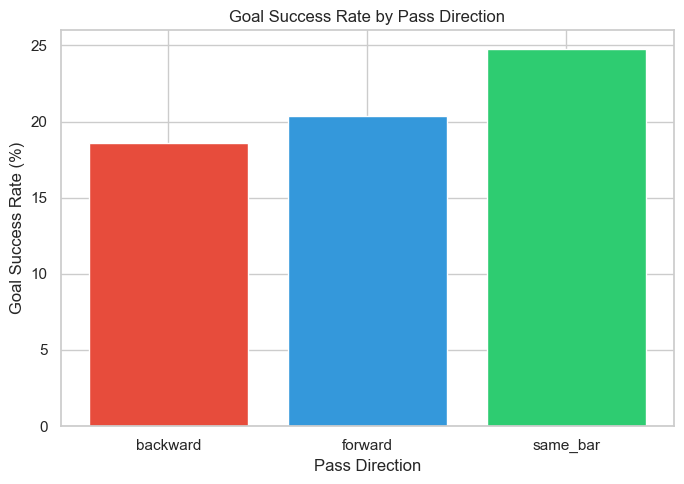

In [165]:
# Keep contact events
contacts_h7 = timestamped_data[timestamped_data["event_type"] == "contact"].copy()
# Clean bar names
contacts_h7["bar_clean"] = contacts_h7["bar"].str.replace(r"\d+", "", regex=True)
# Next action in same possession
contacts_h7["next_bar"] = contacts_h7.groupby("possession_id")["bar_clean"].shift(-1)
# Define field order
bar_order = {"Goal": 0, "Defense": 1, "Middle": 2, "Attack": 3}

# function for pass direction
def get_direction(row):
    if row["bar_clean"] not in bar_order or row["next_bar"] not in bar_order:
        return None  # ignore invalid rows

    if bar_order[row["next_bar"]] > bar_order[row["bar_clean"]]:
        return "forward"
    elif bar_order[row["next_bar"]] < bar_order[row["bar_clean"]]:
        return "backward"
    else:
        return "same_bar"

contacts_h7["direction"] = contacts_h7.apply(get_direction, axis=1)

# Remove invalid classifications
contacts_h7 = contacts_h7.dropna(subset=["direction"])

#Get possession goal outcome 
shot_data = (timestamped_data[timestamped_data["event_type"] == "shot"].groupby("possession_id")["is_goal"].max()
             .reset_index(name="possession_goal"))

contacts_h7 = contacts_h7.merge(shot_data, on="possession_id", how="left")
contacts_h7["possession_goal"] = contacts_h7["possession_goal"].fillna(0)

# Compute success rates
dir_stats = (contacts_h7.groupby("direction")["possession_goal"].agg(["mean", "count"]).reset_index())
dir_stats["success_rate_pct"] = dir_stats["mean"] * 100

#Plot 
plt.figure(figsize=(7, 5))

colors = {"backward": "#e74c3c","forward": "#3498db","same_bar": "#2ecc71"}

bars = plt.bar(dir_stats["direction"],dir_stats["success_rate_pct"],color=[colors[d] for d in dir_stats["direction"]])

plt.title("Goal Success Rate by Pass Direction")
plt.ylabel("Goal Success Rate (%)")
plt.xlabel("Pass Direction")
plt.tight_layout()
plt.show()

The goal success is the highest after passes on the same bar and the lowest after passes in a backward direction.

#### Goal success after passes vs. direct shots

We also looked at the goal success after passes (more than 1 consecutive contact before a shot) versus after direct shots (shot directly after the fist contact).

,shot_type,shots,goals,conversion_rate,conversion_rate_%
0,After pass,3906,915,0.234255,23.425499
1,Direct shot,2460,304,0.123577,12.357724


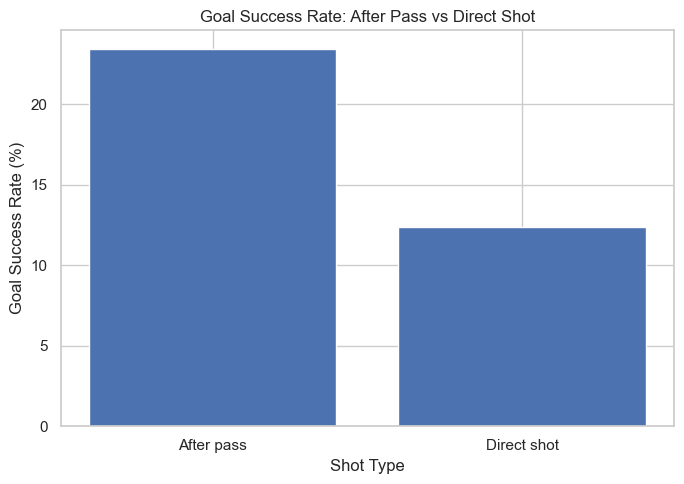

In [166]:
# Compare shots after passes with direct shots
shots_h4 = timestamped_data[timestamped_data["event_type"] == "shot"].copy()

# A possession is counted as "After pass" if it contains at least one valid pass direction
# contacts_h7 already contains valid pass movements: forward, backward, same_bar
pass_possessions = contacts_h7["possession_id"].unique()

shots_h4["shot_type"] = np.where(
    shots_h4["possession_id"].isin(pass_possessions),
    "After pass",
    "Direct shot"
)

pass_success_table = (
    shots_h4
    .groupby("shot_type")
    .agg(
        shots=("event_type", "count"),
        goals=("is_goal", "sum")
    )
    .reset_index()
)

pass_success_table["conversion_rate"] = pass_success_table["goals"] / pass_success_table["shots"]
pass_success_table["conversion_rate_%"] = pass_success_table["conversion_rate"] * 100

display(pass_success_table)

# Plot
plt.figure(figsize=(7, 5))
plt.bar(pass_success_table["shot_type"], pass_success_table["conversion_rate_%"])

plt.title("Goal Success Rate: After Pass vs Direct Shot")
plt.ylabel("Goal Success Rate (%)")
plt.xlabel("Shot Type")
plt.tight_layout()
plt.show()

The average conversion rate is much higher after a pass than after a direct shot.

##### Backward passes per player

We also looked at the amount of backward passes per player.

In [167]:
player_dir_counts = contacts_h7.groupby(["player", "direction"]).size().unstack(fill_value=0)
player_dir_pct = player_dir_counts.div(player_dir_counts.sum(axis=1), axis=0) * 100
backward_magnus = player_dir_counts.loc["Magnus", "backward"]
print(player_dir_pct)

direction   backward    forward  same_bar
player                                   
Diana      48.176718  44.670407  7.152875
Hans       52.782462  37.605396  9.612142
Magnus     54.348767  40.458676  5.192557
Olga       39.868385  55.744447  4.387168
Simon      51.844660  41.407767  6.747573
Tanja      53.473581  39.432485  7.093933


Magnus shows the highest proportion of backward passes and Olga the lowest.

### 4.2.2 Hypotheses

#### Hypothesis 4: Passes have a higher goal success rate than direct shots

H0: The goal conversion rate after passes is less than or equal to the goal conversion rate of direct shots.

H1: The goal conversion rate after passes is higher than the goal conversion rate of direct shots.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Conversion, Pass}}$ as the shot conversion rate (proportion of goals to total shots) after passes and $p_{\text{Conversion, Direct Shot}}$ as the shot conversion rate after a direct shot.

$$H_0: p_{\text{Conversion, Pass}} \le p_{\text{Conversion, Direct Shot}}$$
$$H_1: p_{\text{Conversion, Pass}} > p_{\text{Conversion, Direct Shot}}$$

In [168]:
h4_counts = pass_success_table.set_index("shot_type")

after_pass_goals = h4_counts.loc["After pass", "goals"]
after_pass_shots = h4_counts.loc["After pass", "shots"]

direct_goals = h4_counts.loc["Direct shot", "goals"]
direct_shots = h4_counts.loc["Direct shot", "shots"]

z_stat, p_value = proportions_ztest(
    [after_pass_goals, direct_goals],
    [after_pass_shots, direct_shots],
    alternative="larger"
)

print(f"After Pass Conversion Rate: {(after_pass_goals / after_pass_shots) * 100:.2f}% ({after_pass_goals}/{after_pass_shots})")
print(f"Direct Shot Conversion Rate: {(direct_goals / direct_shots) * 100:.2f}% ({direct_goals}/{direct_shots})")
print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.4e}")

After Pass Conversion Rate: 23.43% (915/3906)
Direct Shot Conversion Rate: 12.36% (304/2460)
Z-Statistic: 10.9282, p-value: 4.2257e-28


The result shows that shots after passes have a higher goal conversion rate than direct shots. Shots after passes resulted in 915 goals from 3906 shots, which gives a conversion rate of 23.43%. Direct shots resulted in 304 goals from 2460 shots, with a conversion rate of 12.36%.

The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis. This means that shots after passes have a significantly higher goal conversion rate than direct shots.

#### Hypothesis 5: Olga passes the ball more than the other Players

H0: There is no statistically significant difference between the length of Olga's ball possessions and the length of the other player's ball possession.

H1: Olga has a statistically significant higher ball possession length than the other players. 

We're using a right-tailed Welch's t-test.

We define $\mu_{\text{Olga}}$ as the mean possession length of Olga's ball possession phases and $\mu_{\text{Others}}$ as the aggregated mean possession length of the other players' phases.

$$H_0: \mu_{\text{Olga}} \le \mu_{\text{Others}}$$
$$H_1: \mu_{\text{Olga}} > \mu_{\text{Others}}$$

In [169]:
olga_possessions = timestamped_data.loc[timestamped_data["player"] == "Olga", "possession_length"]
others_possessions = timestamped_data.loc[timestamped_data["player"] != "Olga", "possession_length"]

t_stat, p_value = stats.ttest_ind(olga_possessions, others_possessions, equal_var=False, alternative="greater")
print(f"p value: {p_value:.4e}")

p value: 4.1800e-142


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 6: The goal success is higher after a pass on the same bar compared to other passes


H0: The goal success rate after a pass on the same bar is less than passing other directions.

H1: The goal's success rate after a same bar pass is significantly higher commpared to other passes.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Conversion, Same Bar}}$ as the shot conversion rate (proportion of goals to total shots) after passes on the same bar and $p_{\text{Conversion, Other Passes}}$ as the shot conversion rate after other passes.

$$H_0: p_{\text{Conversion, Same Bar}} \le p_{\text{Conversion, Other Passes}}$$
$$H_1: p_{\text{Conversion, Same Bar}} > p_{\text{Conversion, Other Passes}}$$


In [170]:
# Split into groups
same_bar = contacts_h7[contacts_h7["direction"] == "same_bar"]
others = contacts_h7[contacts_h7["direction"].isin(["forward", "backward"])]

# Count goals and totals
same_bar_goals = same_bar["possession_goal"].sum()
same_bar_total = len(same_bar)

other_goals = others["possession_goal"].sum()
other_total = len(others)

# Z-test
z_stat, p_val = proportions_ztest([same_bar_goals, other_goals], [same_bar_total, other_total], alternative="larger")

print(f"Same bar: {(same_bar_goals/same_bar_total)*100:.2f}%")
print(f"Others: {(other_goals/other_total)*100:.2f}%")
print(f"p-value: {p_val:.4e}")

Same bar: 24.74%
Others: 19.42%
p-value: 1.4909e-04


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 7: The goal success is higher after back passes (e.g. Attack -> Middle) than after forward passes or direct shots

H0: Success rate of Back Passes is less or equal to the success rate of others.

H1: Success rate of Back Passes is strictly greater than the success rate of others.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Conversion, Backward Pass}}$ as the shot conversion rate after backward passes and $p_{\text{Conversion, Other Passes}}$ as the shot conversion rate after a direct shot.

$$H_0: p_{\text{Conversion, Backward Pass}} \le p_{\text{Conversion, Other Passes}}$$
$$H_1: p_{\text{Conversion, Backward Pass}} > p_{\text{Conversion, Other Passes}}$$

In [171]:
# Split into groups 
back = contacts_h7[contacts_h7["direction"] == "backward"]
others = contacts_h7[contacts_h7["direction"].isin(["forward", "same_bar"])]

# Count goals and totals
back_goals = back["possession_goal"].sum()
back_total = len(back)

other_goals = others["possession_goal"].sum()
other_total = len(others)

# Z-test
z_stat, p_val = proportions_ztest([back_goals, other_goals], [back_total, other_total], alternative="larger")

print(f"Back: {(back_goals/back_total)*100:.2f}%") 
print(f"Others: {(other_goals/other_total)*100:.2f}%")
print(f"Z-stat: {z_stat:.4f}, p-value: {p_val:.4f}")

Back: 18.56%
Others: 20.88%
Z-stat: -3.2712, p-value: 0.9995


Statistical Results: With a p-value of 0.9995, the results are not statistically significant.

Therefore, we fail to reject the null hypothesis. There is not enough evidence to support the claim that back passes lead to a higher goal success rate than forward or same-bar passes.

Although back passes show a slightly lower success rate (18.56%) compared to other passes (20.88%), this difference is not statistically meaningful.

#### Hypothesis 8: Magnus performs more backward passes than the other players.

H0: There is no difference between Magnus and the other players regarding the amount of backward passes.

H1: Magnus takes significantly more backward passes than the other players.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Magnus, back}}$ as the proportion of backward passes out of all passes played by Magnus. Similarly, we define $p_{\text{Others, back}}$ as the combined proportion of backward passes out of all passes played by all other players.

$$H_0: p_{\text{Magnus, back}} \le p_{\text{Others, back}}$$
$$H_1: p_{\text{Magnus, back}} > p_{\text{Others, back}}$$

In [172]:
player_dir_counts = contacts_h7.groupby(["player", "direction"]).size().unstack(fill_value=0)

backward_magnus = player_dir_counts.loc["Magnus", "backward"]
total_magnus = player_dir_counts.loc["Magnus"].sum()
pct_magnus = backward_magnus / total_magnus

other_players = player_dir_counts.index[player_dir_counts.index != "Magnus"]
backward_others = player_dir_counts.loc[other_players, "backward"].sum()
total_others = player_dir_counts.loc[other_players].sum().sum()
pct_others = backward_others / total_others

counts = [backward_magnus, backward_others]
totals = [total_magnus, total_others]

z_statistic, p_value = proportions_ztest(counts, totals, alternative="larger")

print(f"p-value: {p_value:.4e}")

p-value: 1.7187e-09


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 9: Magnus goal success rate is higher for backward passes than for forward passes or direct shots.

H0: There is no statistically significant difference between Magnus' goal conversion rate after backward passes than his goal conversion rate after other passes.

H1: Magnus' goal conversion rate is significantly higher after backward passes than after other passes.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Conversion, Magnus, Backward Pass}}$ as Magnus' shot conversion rate after backward passes and $p_{\text{Conversion, Magnus, Other Passes}}$ as Magnus' shot conversion rate after other passes.

$$H_0: p_{\text{Conversion, Magnus, Backward Pass}} \le p_{\text{Conversion, Magnus, Other Passes}}$$
$$H_1: p_{\text{Conversion, Magnus, Backward Pass}} > p_{\text{Conversion, Magnus, Other Passes}}$$

In [173]:
magnus_data = contacts_h7[contacts_h7["player"] == "Magnus"]

back = magnus_data[magnus_data["direction"] == "backward"]
others = magnus_data[magnus_data["direction"].isin(["forward", "same_bar"])]

back_goals = back["possession_goal"].sum()
back_total = len(back)

other_goals = others["possession_goal"].sum()
other_total = len(others)

z_stat, p_val = proportions_ztest([back_goals, other_goals], [back_total, other_total], alternative="larger")

print(f"p-value: {p_val:.4e}")

p-value: 9.8132e-01


The p-value is not below the threshold. We fail to reject the null hypothesis.

#### Hypothesis 10: Diana has a higher goal success after a same bar pass compared to other passes or direct shots

H0: Diana's goal conversion rate after same-bar passes is less than or equal to her goal conversion rate after other pass directions.

H1: Diana's goal conversion rate after same-bar passes is higher than her goal conversion rate after other pass directions.


We're using a right-tailed Z-test for proportions.

We define $p_{\text{Conversion, Diana, Same Bar}}$ as Olga's shot conversion rate after a pass on the same bar and $p_{\text{Conversion, Diana, Other Passes}}$ as Olga's shot conversion rate after other passes

$$H_0: p_{\text{Conversion, Diana, Same Bar}} \le p_{\text{Conversion, Diana, Other Passes}}$$
$$H_1: p_{\text{Conversion, Diana, Same Bar}} > p_{\text{Conversion, Diana, Other Passes}}$$

In [174]:
diana_same_bar_possessions = contacts_h7[
    (contacts_h7["player"] == "Diana") &
    (contacts_h7["direction"] == "same_bar")
]["possession_id"].unique()

diana_shots_h8 = timestamped_data[
    (timestamped_data["event_type"] == "shot") &
    (timestamped_data["player"] == "Diana")
].copy()

diana_shots_h8["pass_type"] = np.where(
    diana_shots_h8["possession_id"].isin(diana_same_bar_possessions),
    "After same-bar pass",
    "After other/no pass"
)

same_bar = diana_shots_h8[diana_shots_h8["pass_type"] == "After same-bar pass"]
other_passes = diana_shots_h8[diana_shots_h8["pass_type"] == "After other/no pass"]

same_bar_goals = same_bar["is_goal"].sum()
same_bar_shots = same_bar["is_shot"].sum()

other_goals = other_passes["is_goal"].sum()
other_shots = other_passes["is_shot"].sum()

z_stat, p_value = proportions_ztest(
    [same_bar_goals, other_goals],
    [same_bar_shots, other_shots],
    alternative="larger"
)

print(f"Diana Same-Bar Pass Conversion Rate: {(same_bar_goals / same_bar_shots) * 100:.2f}% ({same_bar_goals}/{same_bar_shots})")
print(f"Diana Other/No Pass Conversion Rate: {(other_goals / other_shots) * 100:.2f}% ({other_goals}/{other_shots})")
print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.6f}")

Diana Same-Bar Pass Conversion Rate: 43.70% (52/119)
Diana Other/No Pass Conversion Rate: 22.79% (188/825)
Z-Statistic: 4.8971, p-value: 0.000000


he result shows that Diana has a higher goal conversion rate after same-bar passes. Diana scored 52 goals from 119 shots after same-bar passes, which gives a conversion rate of 43.70%. After other or no passes, she scored 188 goals from 825 shots, with a conversion rate of 22.79%.

The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis. This means that Diana's goal conversion rate after same-bar passes is significantly higher than after other or no passes.

## 4.3 Shot Execution and Offensive Efficiency

### 4.3.1 Plots and Results

#### Shot Conversion Rate

In [175]:
player_conversion_rate = timestamped_data.groupby('player').agg(shots=('is_shot','sum'), goals=('is_goal', 'sum')).reset_index()
player_conversion_rate['conversion_rate'] = (player_conversion_rate['goals'] / player_conversion_rate['shots'])
player_conversion_rate.sort_values(by='conversion_rate', ascending=False)

,player,shots,goals,conversion_rate
3,Olga,664,223,0.335843
0,Diana,944,240,0.254237
2,Magnus,1002,186,0.185629
5,Tanja,1141,189,0.165644
4,Simon,1368,219,0.160088
1,Hans,1247,162,0.129912


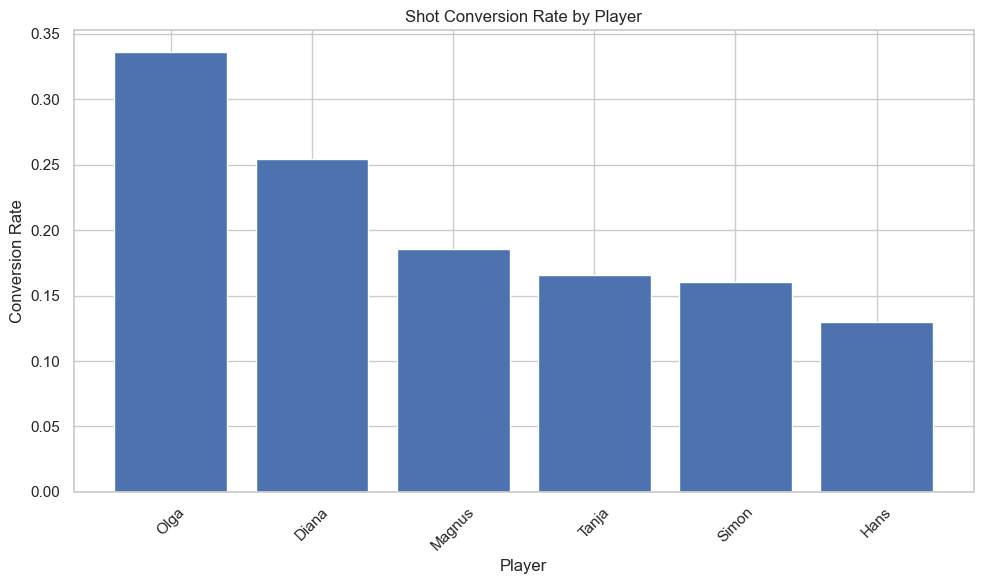

In [176]:
player_conversion_rate = player_conversion_rate.sort_values(
    by='conversion_rate',
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.bar(
    player_conversion_rate['player'],
    player_conversion_rate['conversion_rate'])

plt.title('Shot Conversion Rate by Player')
plt.xlabel('Player')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [177]:
conversion_situational = shots.groupby(["player", "situation"])["is_goal"].mean() * 100

order = ["more points", "tie", "fewer points"]
conversion_situational = conversion_situational.unstack(fill_value=0).reindex(columns=order)

print(conversion_situational.round(1))

situation  more points   tie  fewer points
player                                    
Diana             26.1  23.8          27.1
Hans               8.6  14.4          13.7
Magnus            20.6  19.4          15.8
Olga              33.3  34.0          33.6
Simon             15.3  18.2          16.5
Tanja             21.5  16.4          15.3


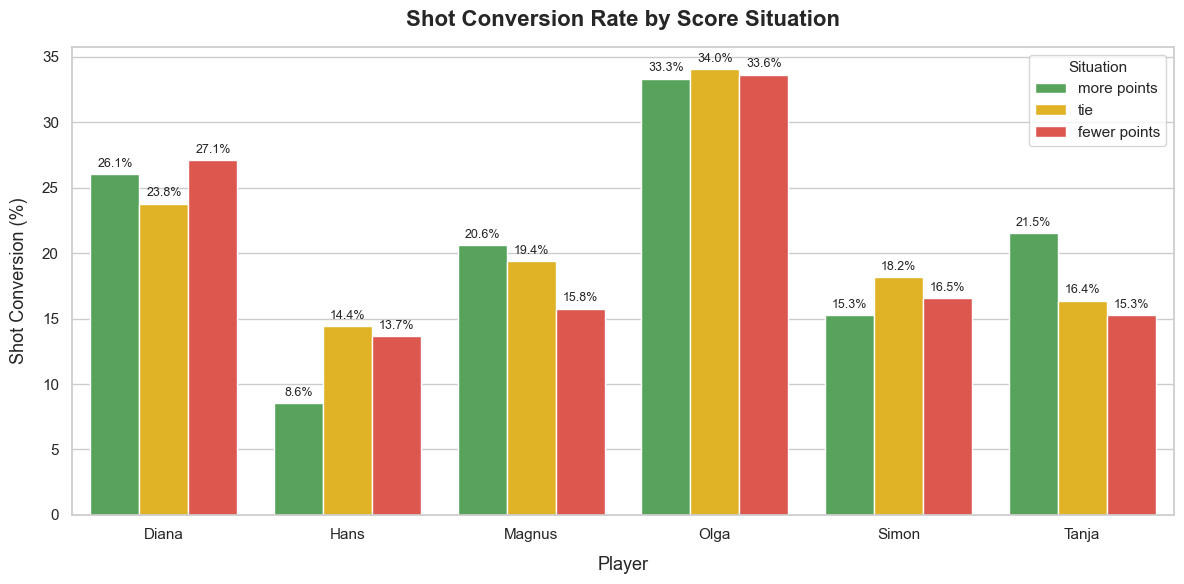

In [178]:
plot_data = conversion_situational.reset_index().melt(
    id_vars="player", 
    var_name="Match Situation", 
    value_name="Shot Conversion (%)")

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=plot_data,
    x="player",
    y="Shot Conversion (%)",
    hue="Match Situation",
    palette=["#4CAF50", "#FFC107", "#F44336"] )

plt.title("Shot Conversion Rate by Score Situation", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Player", fontsize=13, labelpad=10)
plt.ylabel("Shot Conversion (%)", fontsize=13, labelpad=10)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Situation", title_fontsize='11', loc="upper right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

#### Simon Long Shots

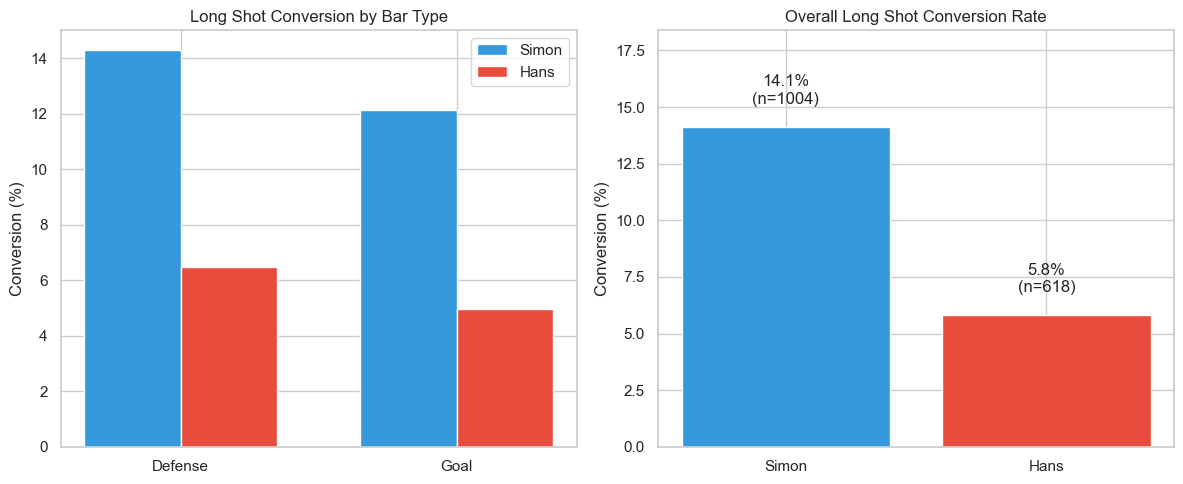

In [179]:
# Get shot events
shots_h14 = timestamped_data[timestamped_data["event_type"] == "shot"].copy()
# Clean bar names
shots_h14["bar_clean"] = shots_h14["prev_bar"].str.replace(r"\d+", "", regex=True)

# Filter for long shots
long_shots_h14 = shots_h14[shots_h14["bar_clean"].isin(["Goal", "Defense"]) & shots_h14["player"].isin(["Simon", "Hans"])].copy()

long_shots_h14["is_goal_int"] = long_shots_h14["is_goal"].astype(int)

# Conversion per bar
bar_conv_h14 = (long_shots_h14.groupby(["player", "bar_clean"])["is_goal_int"].agg(["sum", "count"]).reset_index())
bar_conv_h14["conv_pct"] = bar_conv_h14["sum"] / bar_conv_h14["count"] * 100

# Overall conversion per player
total_conv_h14 = (long_shots_h14.groupby("player")["is_goal_int"].agg(["sum", "count"]).reset_index())
total_conv_h14["conv_pct"] = total_conv_h14["sum"] / total_conv_h14["count"] * 100

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
bars = sorted(bar_conv_h14["bar_clean"].unique())
x = np.arange(len(bars))
width = 0.35

# Left plot (by bar type)
def get_val(df, player, bar):
    match = df[(df["player"] == player) & (df["bar_clean"] == bar)]
    return match["conv_pct"].values[0] if len(match) else 0

axes[0].bar(x - width/2, [get_val(bar_conv_h14, "Simon", b) for b in bars], width, label="Simon", color="#3498db")
axes[0].bar(x + width/2, [get_val(bar_conv_h14, "Hans", b) for b in bars], width, label="Hans", color="#e74c3c")

axes[0].set_xticks(x)
axes[0].set_xticklabels(bars)
axes[0].set_title("Long Shot Conversion by Bar Type")
axes[0].set_ylabel("Conversion (%)")
axes[0].legend()

# Right plot (Overall long shots)
players = ["Simon", "Hans"]
colors = ["#3498db", "#e74c3c"]

axes[1].set_ylim(0, total_conv_h14["conv_pct"].max() * 1.3)
for i, (p, c) in enumerate(zip(players, colors)):
    row = total_conv_h14[total_conv_h14["player"] == p].iloc[0]

    axes[1].bar(p, row["conv_pct"], color=c)

    axes[1].text(i, row["conv_pct"] + 1, f"{row['conv_pct']:.1f}%\n(n={int(row['count'])})", ha="center")

axes[1].set_title("Overall Long Shot Conversion Rate")
axes[1].set_ylabel("Conversion (%)")
plt.tight_layout()
plt.show()

#### Shot Conversion Rate by Bar

In [180]:
bar_stats = shots.groupby("prev_bar_clean")["is_goal"].agg(total_shots="count",goals="sum",conversion_rate="mean").reset_index()
bar_stats.sort_values(by='conversion_rate', ascending=False)

,prev_bar_clean,total_shots,goals,conversion_rate
0,Attack,1798,650,0.361513
3,Middle,1504,223,0.148271
1,Defense,1980,244,0.123232
2,Goal,803,65,0.080946


#### Left Side Percentages

In [181]:
player_side_percentages = timestamped_data[timestamped_data['is_shot']].groupby('player')['prev_side_normalized'].value_counts(normalize=True).reset_index(name='percentage')
player_side_percentages['percentage'] = player_side_percentages['percentage'] * 100

left_side_shots = player_side_percentages[player_side_percentages['prev_side_normalized'] == 'Left']
left_side_shots.sort_values(by='percentage', ascending=False)

,player,prev_side_normalized,percentage
0,Diana,Left,66.313559
5,Hans,Left,27.826784
8,Magnus,Left,26.746507
14,Simon,Left,26.096491
11,Olga,Left,23.945783
17,Tanja,Left,21.472393


### Diana shoots the most from Attack and Middle bar

In [182]:
# Look at contacts exactly before the shot
df_hx = timestamped_data.copy()
df_hx["prev_bar"] = df_hx.groupby(["game", "run_id"])["bar"].shift(1)

shots_hx = df_hx[df_hx["event_type"] == "shot"].copy()

# Clean the bar names
shots_hx["bar_clean"] = shots_hx["prev_bar"].str.replace(r'\d+', '', regex=True)

# Create a boolean flag for whether the shot came from the front bars
shots_hx["is_front_shot"] = shots_hx["bar_clean"].isin(["Attack", "Middle"])

#Split the data into Diana vs Other Players
diana_shots = shots_hx[shots_hx["player"] == "Diana"]
other_shots = shots_hx[shots_hx["player"] != "Diana"]
# Count the shots from the front bars
count = np.array([diana_shots["is_front_shot"].sum(), other_shots["is_front_shot"].sum()])
nobs = np.array([len(diana_shots), len(other_shots)])

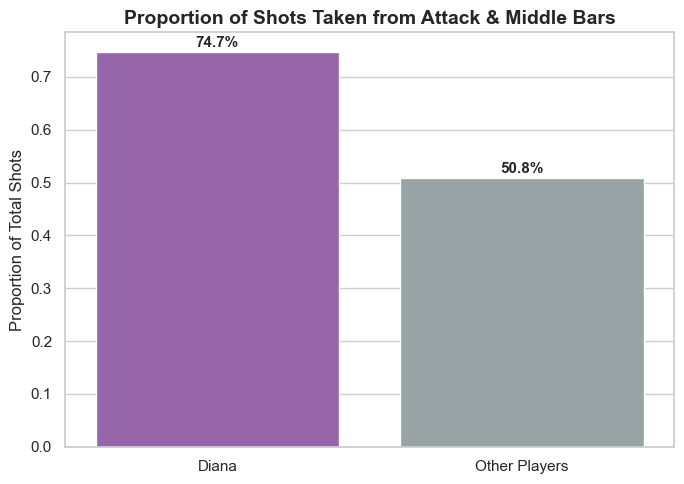

In [183]:
# Plot
plt.figure(figsize=(7, 5))

# Calculate rates for plotting
diana_rate = count[0] / nobs[0]
others_rate = count[1] / nobs[1]

# Create the bar plot
sns.barplot(x=["Diana", "Other Players"], y=[diana_rate, others_rate], hue=["Diana", "Other Players"], palette=["#9b59b6", "#95a5a6"], 
            legend=False)

plt.title("Proportion of Shots Taken from Attack & Middle Bars", fontsize=14, fontweight="bold")
plt.ylabel("Proportion of Total Shots", fontsize=12)

# Add percentages above the bars
plt.text(0, diana_rate + 0.01, f"{diana_rate*100:.1f}%", ha='center', fontweight='bold', fontsize=11)
plt.text(1, others_rate + 0.01, f"{others_rate*100:.1f}%", ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

### 4.3.2 Hypotheses

#### Hypothesis 11: Olga demonstrates the highest shot conversion rate.

H0: There is no statistically significant difference between Olga's shot conversion rate and the conversion rate of the other players.

H1: Olga has a statistically significant higher shot conversion rate compared to the other players.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Olga}}$ as the shot conversion rate (proportion of goals to total shots) of Olga and $p_{\text{Others}}$ as the aggregated shot conversion rate of the other players.

$$H_0: p_{\text{Olga}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Olga}} > p_{\text{Others}}$$

In [184]:
olga_goals = timestamped_data.loc[timestamped_data['player'] == 'Olga', 'is_goal'].sum()
olga_shots = timestamped_data.loc[timestamped_data['player'] == 'Olga', 'is_shot'].sum()

others_goals = timestamped_data.loc[timestamped_data['player'] != 'Olga', 'is_goal'].sum()
others_shots = timestamped_data.loc[timestamped_data['player'] != 'Olga', 'is_shot'].sum()

goals = [olga_goals, others_goals]
observations = [olga_shots, others_shots]

z_stat, p_value = proportions_ztest(goals, observations, alternative='larger')

print(f"p value: {p_value:.4e}")

p value: 8.4981e-24


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 12: Players who have a attack bias scores a higher number of goals compared to the other players.

**H0**: There is no statistically significant correlation between attack bias and goals scored by players.

**H1**: Players have a statistically significant positive correlation between attack bias and goal scored.

We're using a two-tailed Pearson correlation test. 

We define $\rho$ as the Pearson correlation coefficient between the attack bias and the number of goals scored by the players.

$$H_0: \rho = 0$$
$$H_1: \rho \neq 0$$

In [185]:
# Extracting attack specific data 
group_cols = ["player", "game"] 
contacts = timestamped_data[timestamped_data["event_type"] == "contact"]
total_contacts = contacts.groupby(group_cols).size()
attack_contact = contacts[contacts["bar"].str.contains("Attack", na=False)].groupby(group_cols).size()  # strips Attack1 to Attack
# We need 2 main  features 'Attack Bias' & 'Total Goals'
attack_bias = (attack_contact / total_contacts).rename("attack_bias").fillna(0)
goals = timestamped_data[(timestamped_data["event_type"] == "shot") & (timestamped_data["is_goal"] == True)]
total_goals = goals.groupby(group_cols).size().rename("total_goals")
player_h2 = pd.concat([attack_bias,total_goals], axis=1).fillna(0)
# Testing the co-relation using stats.pearson

correlation, p_value = stats.pearsonr(player_h2['attack_bias'], player_h2['total_goals'])

print(f"p_value = {p_value:.4f}")
print(correlation)


p_value = 0.5357
0.11768859471281078


In [186]:
player_h2

attack_bias  total_goals
player game                                  
Diana  Diana-Hans       0.225806           50
       Diana-Magnus     0.233937           45
       Diana-Olga       0.257658           50
       Diana-Simon      0.257603           45
       Diana-Tanja      0.227941           50
Hans   Diana-Hans       0.154008           24
       Hans-Magnus      0.221311           35
       Hans-Olga        0.219959           30
       Hans-Simon       0.231237           27
       Hans-Tanja       0.220109           46
Magnus Diana-Magnus     0.172596           33
       Hans-Magnus      0.197115           50
       Magnus-Olga      0.227053           33
       Magnus-Simon     0.207273           35
       Magnus-Tanja     0.204268           35
Olga   Diana-Olga       0.188488           35
       Hans-Olga        0.186457           49
       Magnus-Olga      0.203640           44
       Olga-Simon       0.217687           45
       Olga-Tanja       0.182416           50
Simon  Diana-Simon      0.139183           36
       Hans-Simon       0.153153           50
       Magnus-Simon     0.184874           47
       Olga-Simon       0.171390           42
       Simon-Tanja      0.155828           44
Tanja  Diana-Tanja      0.187402           30
       Hans-Tanja       0.173505           47
       Magnus-Tanja     0.185065           38
       Olga-Tanja       0.215262           35
       Simon-Tanja      0.209268           39

Statistical Results:
With a p-value of $0.54$, the results are not statistically significant.

Therefore, we cannot reject the null hypothesis. There is no evidence in this data to support the claim that a higher attack bias leads to a greater number of goals.

#### Hypothesis 13: Diana shoots more shots from the left side than the other players

H0: There is no significant difference in the amount of shots taken from the left side for Diana compared to the other players

H1: Diana takes significantly more shots from the left side than the other players.


We're using a right-tailed Z-test for proportions.

We define $p_{\text{Diana}}$ as the proportion of shots taken from the left side by Diana and $p_{\text{Others}}$ as the aggregated proportion of shots taken from the left side by the other players.

$$H_0: p_{\text{Diana}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Diana}} > p_{\text{Others}}$$

In [187]:
diana_left = timestamped_data[(timestamped_data['player'] == 'Diana') & (timestamped_data['is_shot'] == True) & (timestamped_data['prev_side_normalized'] == 'Left')].shape[0]
diana_total_shots = timestamped_data[(timestamped_data['player'] == 'Diana') & (timestamped_data['is_shot'] == True)].shape[0]

others_left = timestamped_data[(timestamped_data['player'] != 'Diana') & (timestamped_data['is_shot'] == True) & (timestamped_data['prev_side_normalized'] == 'Left')].shape[0]
others_total_shots = timestamped_data[(timestamped_data['player'] != 'Diana') & (timestamped_data['is_shot'] == True)].shape[0]

successes = [diana_left, others_left]
observations = [diana_total_shots, others_total_shots]

z_stat, p_value = proportions_ztest(successes, observations, alternative='larger')

print(f"p value: {p_value:.4e}")

p value: 3.1260e-138


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 14: Shots taken from the Defense bar or Goal bar have a lower goal conversion rate compared to shots from Middle/Attack bar

H0: There is no significant difference in the success of shots taken from the Defense or Goal bar compared to the success of shots taken from the Middle or Attack bar.

H1: Shots taken from the Defense or Goal bar are significantly less successful than shots taken from the Middle or Attack bar. 

We're using a left-tailed Z-test for proportions.

We define $p_{\text{Def/Goal}}$ as the goal conversion rate of shots taken from the defense or goal bars, and $p_{\text{Mid/Att}}$ as the conversion rate of shots taken from the middle or attack bars.

$$H_0: p_{\text{Def/Goal}} \ge p_{\text{Mid/Att}}$$
$$H_1: p_{\text{Def/Goal}} < p_{\text{Mid/Att}}$$

In [188]:
def_goal_shots = shots[shots["prev_bar_clean"].isin(["Defense", "Goal"])]
mid_att_shots = shots[shots["prev_bar_clean"].isin(["Middle", "Attack"])]

success_def_goal = def_goal_shots["is_goal"].sum()
obs_def_goal = def_goal_shots.shape[0]

success_mid_att = mid_att_shots["is_goal"].sum()
obs_mid_att = mid_att_shots.shape[0]

successes = [success_def_goal, success_mid_att]
observations = [obs_def_goal, obs_mid_att]

z_stat, p_value = proportions_ztest(successes, observations, alternative='smaller')
print(f"p value: {p_value:.4e}")

p value: 1.4038e-51


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 15: Simon and Hans take more shots from the Goal and Defense bar than the other players.

H0: There is no significant difference in the amount of shots taken from the Defense or Goal bar for Simon and Hans compared to the success of shots for other playrs.

H1: Simon and Hans take significantly more shots from the Defense or Goal bar than the other players.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Simon, Hans}}$ as the proportion of shots taken from the Defense or Goal bar by Simon and Hans and $p_{\text{Others}}$ as the aggregated proportion of shots taken from the Defense or Goal bar by the other players.

$$H_0: p_{\text{Simon, Hans}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Simon, Hans}} > p_{\text{Others}}$$

In [189]:
# Filter long shots for all players
all_long_shots = shots[shots["prev_bar_clean"].isin(["Goal", "Defense"])]

# Split by group
simon_hans_long = all_long_shots[all_long_shots["player"].isin(["Simon", "Hans"])]
others_long = all_long_shots[all_long_shots["player"].isin(["Diana", "Olga", "Tanja", "Magnus"])]

# Count long shots per group
shot_long = simon_hans_long.shape[0]
others_long = others_long.shape[0]

# Total shots per group (denominator)
shot_total = shots[shots["player"].isin(["Simon", "Hans"])].shape[0]
others_total = shots[shots["player"].isin(["Diana", "Olga", "Tanja", "Magnus"])].shape[0]

successes = [shot_long, others_long]
observations = [shot_total, others_total]

z_stat, p_value = proportions_ztest(successes, observations, alternative="larger")

print(f"p value: {p_value:.4e}")

p value: 1.7465e-109


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

#### Hypothesis 16: Simon is more successful for his long shots than Hans. 

H0: Simon's long shot conversion rate is less or equal to Hans's conversion rate.

H1: Simon's long shot conversion rate is greater than Hans's conversion rate.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Simon}}$ as the shot conversion rate of Simon's shots from the Defense or Goal bar and $p_{\text{Hans}}$ as the shot conversion rate of Hans' shots from the Defense or Goal bar

$$H_0: p_{\text{Simon}} \le p_{\text{Hans}}$$
$$H_1: p_{\text{Simon}} > p_{\text{Hans}}$$

In [190]:
# Split by players
simon_h14 = long_shots_h14[long_shots_h14["player"] == "Simon"]
hans_h14 = long_shots_h14[long_shots_h14["player"] == "Hans"]

# Count goal and shots for each
simon_goals = simon_h14["is_goal_int"].sum()
simon_shots = len(simon_h14)

hans_goals = hans_h14["is_goal_int"].sum()
hans_shots = len(hans_h14)

# Z-test
z_stat, p_val = proportions_ztest([simon_goals, hans_goals],[simon_shots, hans_shots],alternative="larger")

# Array to compare
rates = np.array([simon_goals / simon_shots,hans_goals / hans_shots])
z_scores = (rates - rates.mean()) / (rates.std() + 1e-9)

print(f"Simon: {simon_goals}/{simon_shots} = {rates[0]*100:.2f}%")
print(f"Hans : {hans_goals}/{hans_shots} = {rates[1]*100:.2f}%")
print(f"p-value: {p_val}")

Simon: 142/1004 = 14.14%
Hans : 36/618 = 5.83%
p-value: 9.699399637298483e-08


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

There is strong evidence to support the claim that Simon has a higher long-shot goal conversion rate than Hans.

There is a clear difference in long-shot performance, with Simon converting 14.14% of long shots compared to 5.83% for Hans.

#### Hypothesis 17: Hans has a lower conversion rate than the other players

H0: Hans's shot conversion rate is greater than or equal to the shot conversion rate of the other players.

H1: Hans's shot conversion rate is lower than the shot conversion rate of the other players.

We're using a left-tailed Z-test for proportions.

We define $p_{\text{Hans}}$ as the proportion of successful shots by Hans and $p_{\text{Others}}$ as the aggregated proportion of successful shots taken by other players.

$$H_0: p_{\text{Hans}} \ge p_{\text{Others}}$$
$$H_1: p_{\text{Hans}} < p_{\text{Others}}$$

In [191]:
hans_goals = timestamped_data.loc[
    timestamped_data["player"] == "Hans", "is_goal"
].sum()

hans_shots = timestamped_data.loc[
    timestamped_data["player"] == "Hans", "is_shot"
].sum()

others_goals = timestamped_data.loc[
    timestamped_data["player"] != "Hans", "is_goal"
].sum()

others_shots = timestamped_data.loc[
    timestamped_data["player"] != "Hans", "is_shot"
].sum()

hans_rate = hans_goals / hans_shots * 100 if hans_shots > 0 else 0
others_rate = others_goals / others_shots * 100 if others_shots > 0 else 0

z_statistic, p_value = proportions_ztest(
    count=[hans_goals, others_goals],
    nobs=[hans_shots, others_shots],
    alternative="smaller"
)

print(f"Hans Conversion Rate: {hans_rate:.2f}% ({hans_goals}/{hans_shots})")
print(f"Other Players Conversion Rate: {others_rate:.2f}% ({others_goals}/{others_shots})")
print(f"Z-Statistic: {z_statistic:.4f}, p-value: {p_value:.6f}")

Hans Conversion Rate: 12.99% (162/1247)
Other Players Conversion Rate: 20.65% (1057/5119)
Z-Statistic: -6.1626, p-value: 0.000000


The result shows that Hans has a lower goal conversion rate than the other players. Hans scored 162 goals from 1247 shots, which gives a conversion rate of 12.99%. The other players scored 1057 goals from 5119 shots, with a conversion rate of 20.65%.

The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis. This means that Hans' goal conversion rate is significantly lower than the goal conversion rate of the other players.

#### Hypothesis 18: Tanja and Magnus have a drop in conversion rate when they have fewer points than the opponent

H0a: There is no significant difference in Tanja's conversion rate when she has fewer points than the opponent compared to when she has more points than the opponent.

H1a: Tanja's shot conversion rate is significantly lower when she has fewer points than the opponent compared to when she has more points than the opponent.

H0b: There is no significant difference in Magnus' conversion rate when he has fewer points than the opponent compared to when he has more points than the opponent.

H1b: Magnus' shot conversion rate is significantly lower when he has fewer points than the opponent compared to when he has more points than the opponent.

We're using a left-tailed Z-test for proportions.

We define $p_{\text{Tanja, less}}$ and $p_{\text{Tanja, more}}$ as Tanja's shot conversion rates when she has fewer points and more points than the opponent, respectively. Similarly, we define $p_{\text{Magnus, less}}$ and $p_{\text{Magnus, more}}$ as Magnus's shot conversion rates under the same respective conditions.


$$H_{0a}: p_{\text{Tanja, fewer}} \ge p_{\text{Tanja, more}}$$
$$H_{1a}: p_{\text{Tanja, fewer}} < p_{\text{Tanja, more}}$$


$$H_{0b}: p_{\text{Magnus, fewer}} \ge p_{\text{Magnus, more}}$$
$$H_{1b}: p_{\text{Magnus, fewer}} < p_{\text{Magnus, more}}$$

In [192]:
count_fewer_tanja = shots[(shots["player"] == "Tanja") & (shots["situation"] == "fewer points")]["is_goal"].sum()
total_fewer_tanja = shots[(shots["player"] == "Tanja") & (shots["situation"] == "fewer points")].shape[0]

count_winning_tanja = shots[(shots["player"] == "Tanja") & (shots["situation"] == "more points")]["is_goal"].sum()
total_winning_tanja = shots[(shots["player"] == "Tanja") & (shots["situation"] == "more points")].shape[0]

counts_tanja = [count_fewer_tanja, count_winning_tanja]
totals_tanja = [total_fewer_tanja, total_winning_tanja]

z_statistic, p_value = proportions_ztest(counts_tanja, totals_tanja, alternative="smaller")
print(f"Tanja p-value: {p_value:.6f}")

Tanja p-value: 0.015326


The p-value for Tanja is above the significance threshold after alpha adjustment. Therefore we cannot reject the null hypothesis in favor of the alternative hypothesis although there is a strong tendency of Tanja to have a lower conversion rate when having fewer points than the opponent versus when having more points than the opponent.

In [193]:
count_fewer_magnus = shots[(shots["player"] == "Magnus") & (shots["situation"] == "fewer points")]["is_goal"].sum()
total_fewer_magnus = shots[(shots["player"] == "Magnus") & (shots["situation"] == "fewer points")].shape[0]

count_winning_magnus = shots[(shots["player"] == "Magnus") & (shots["situation"] == "more points")]["is_goal"].sum()
total_winning_magnus = shots[(shots["player"] == "Magnus") & (shots["situation"] == "more points")].shape[0]

counts_magnus = [count_fewer_magnus, count_winning_magnus]
totals_magnus = [total_fewer_magnus, total_winning_magnus]

z_statistic, p_value = proportions_ztest(counts_magnus, totals_magnus, alternative="smaller")
print(f"Magnus p-value: {p_value:.6f}")

Magnus p-value: 0.035246


The p-value for Magnus is also above the significance threshold after alpha adjustment and also a bit higher than the one for Tanja. Therefore we cannot reject the null hypothesis in favor of the alternative hypothesis. But he also shows a strong tendency to have a lower conversion rate when having fewer points than the opponent versus when having more points than the opponent.

#### Hypothesis 19: Hans has an increase in conversion rate when he has fewer points than the opponent

H0: There is no significant difference in Hans' conversion rate when he has fewer points than the opponent compared to when he has more points than the opponent.

H1: Hans' shot conversion rate is significantly higher when he has fewer points than the opponent compared to when he has more points than the opponent.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Hans, fewer}}$ and $p_{\text{Hans, more}}$ as Hans' shot conversion rates when he has fewer points and more points than the opponent, respectively. 

$$H_{0a}: p_{\text{Hans, fewer}} \ge p_{\text{Hans, more}}$$
$$H_{1a}: p_{\text{Hans, fewer}} < p_{\text{Hans, more}}$$

In [194]:
count_fewer_hans = shots[(shots["player"] == "Hans") & (shots["situation"] == "fewer points")]["is_goal"].sum()
total_fewer_hans = shots[(shots["player"] == "Hans") & (shots["situation"] == "fewer points")].shape[0]

count_winning_hans = shots[(shots["player"] == "Hans") & (shots["situation"] == "more points")]["is_goal"].sum()
total_winning_hans = shots[(shots["player"] == "Hans") & (shots["situation"] == "more points")].shape[0]

counts_hans = [count_fewer_hans, count_winning_hans]
totals_hans = [total_fewer_hans, total_winning_hans]

z_statistic, p_value = proportions_ztest(counts_hans, totals_hans, alternative="larger")
print(f"p-value: {p_value:.6f}")

p-value: 0.034275


The p-value is above the significance threshold after alpha adjustment. Therefore we cannot reject the null hypothesis in favor of the alternative hypothesis although there is a strong tendency of Hans to have a higher conversion rate when having fewer points than the opponent versus when having more points than the opponent.

#### Hypothesis 20: Diana shoots more shots from the Attack and Middle bar than the other players.

H0: The proportion of Diana's shots from the Attack/Middle bars is less or equal the proportion for other players.

H1: The proportion of Diana's shots from the Attack/Middle bars is strictly greater than other players.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Diana}}$ as the proportion of shots taken from the Attack or Middle bar by Diana and $p_{\text{Others}}$ as the proportion of shots taken from the Attack or Middle bar by other players.

$$H_0: p_{\text{Diana}} \le p_{\text{Others}}$$
$$H_1: p_{\text{Diana}} > p_{\text{Others}}$$

In [195]:
# Z-Test
z_stat, p_val = proportions_ztest(count, nobs, alternative='larger')

print(f"Diana's Attack and Middle Bar-Shot Rate: {(count[0]/nobs[0])*100:.2f}% (n={nobs[0]} total shots)")
print(f"Others' Attack and Middle Bar-Shot Rate: {(count[1]/nobs[1])*100:.2f}% (n={nobs[1]} total shots)\n")

print(f"Z-Statistic: {z_stat}")
print(f"P-Value: {p_val}\n")

Diana's Attack and Middle Bar-Shot Rate: 74.68% (n=944 total shots)
Others' Attack and Middle Bar-Shot Rate: 50.79% (n=5422 total shots)

Z-Statistic: 13.598836588618331
P-Value: 2.0342690624231546e-42



The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis. There is sufficient evidence to support the claim that Diana shoots more shots from the Attack and Middle bar than the other players. 

## 4.4 Defensive Behaviour

### 4.4.1 Plots and Results

#### Player Defensive Recovery Rate

In [196]:
players = timestamped_data["player"].dropna().unique()
stats_list = []

# Track what happens immediately after each event with shifted columns
df_h17 = timestamped_data.copy()
df_h17["next_player"] = df_h17.groupby(["game", "run_id"])["player"].shift(-1)
df_h17["next_bar"] = df_h17.groupby(["game", "run_id"])["bar"].shift(-1)

#Loop through each player
for p in players:

    games = round_data[(round_data["player_1"] == p) | (round_data["player_2"] == p)]
    # Calculate win_rate
    win_rate = (games["round_winner"] == p).mean() if len(games) > 0 else 0
    # Find shots by the opponent while this player is involved in the round 
    opp_shots = df_h17[(df_h17["event_type"] == "shot") & (df_h17["player"] != p) & ((df_h17["player_1"] == p) | (df_h17["player_2"] == p))]
    # Check if the player regains possession immediately after the shot and the next action happens in a defensive area
    recoveries = opp_shots[(opp_shots["next_player"] == p) & (opp_shots["next_bar"].str.contains("Defense|Goal", na=False))]

    # Recovery rate = successful recoveries / total opponent shots
    recov_rate = len(recoveries) / len(opp_shots) if len(opp_shots) > 0 else 0

    #Store results for each player
    stats_list.append({"Player": p, "Round Win Rate": win_rate, "Recovery Rate": recov_rate})

recov_df = pd.DataFrame(stats_list)

In [197]:
recov_df.sort_values(by="Recovery Rate", ascending=False)

,Player,Round Win Rate,Recovery Rate
4,Simon,0.534146,0.581612
2,Magnus,0.470886,0.567704
0,Diana,0.603015,0.554180
5,Tanja,0.456522,0.552365
3,Olga,0.539952,0.546132
1,Hans,0.397059,0.504578


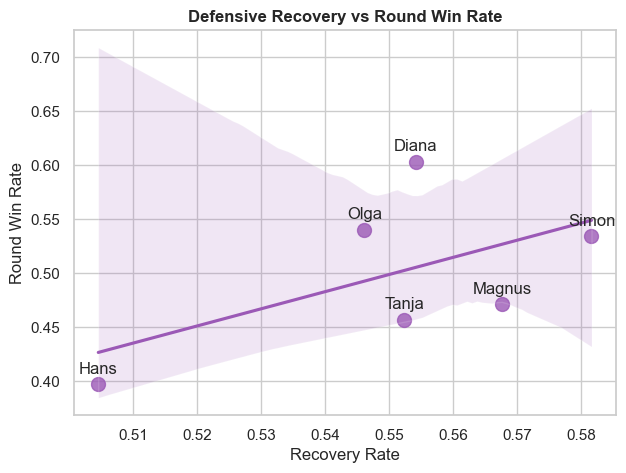

In [198]:
plt.figure(figsize=(7, 5))
sns.regplot(data=recov_df, x="Recovery Rate", y="Round Win Rate", color="#9b59b6", scatter_kws={'s':100})
for i, row in recov_df.iterrows():
    plt.text(row["Recovery Rate"], row["Round Win Rate"]+0.01, row["Player"], horizontalalignment='center')
plt.title("Defensive Recovery vs Round Win Rate", fontweight="bold")
plt.show()

### 4.4.2 Hypotheses

#### Hypothesis 21: Simon and Magnus show more defensive recovery behaviour than the other players

H0a: There is no statistically significant difference between the proportion of defensive recovery behaviour of Simon and the proportion of defensive recovery behaviour of the other players.

H1a: Simon has a statistically significant higher proportion of defensive recovery behaviour than the other players.

H0b: There is no statistically significant difference between the proportion of defensive recovery behaviour of Magnus and the proportion of defensive recovery behaviour of the other players.

H1b: Magnus has a statistically significant higher proportion of defensive recovery behaviour than the other players.


We're using a right-tailed Z-tests for proportions.

We define $p_{\text{Simon}}$ as the proportion of the defensive recovery behaviour of Simon and $p_{\text{Others}}$ as the proportion of the defensive behaviour of the other.
Similarly, we define $p_{\text{Magnus}}$ as the proportion of the defensive recovery behaviour of Simon and $p_{\text{Others}}$ as the proportion of the defensive behaviour of the other.


$$H_{0a}: p_{\text{Simon}} \le p_{\text{Others}}$$
$$H_{1a}: p_{\text{Simon}} > p_{\text{Others}}$$


$$H_{0b}: p_{\text{Magnus}} \le p_{\text{Others}}$$
$$H_{1b}: p_{\text{Magnus}} > p_{\text{Others}}$$

In [199]:
df_h16 = timestamped_data.copy()

df_h16["next_player"] = df_h16.groupby(["game", "run_id"])["player"].shift(-1)
df_h16["next_bar"] = df_h16.groupby(["game", "run_id"])["bar"].shift(-1)

target_players = ["Simon", "Magnus"]

for target_player in target_players:
    
    target_opp_shots = df_h16[
        (df_h16["event_type"] == "shot") &
        (df_h16["player"] != target_player) &
        (
            (df_h16["player_1"] == target_player) |
            (df_h16["player_2"] == target_player)
        )
    ]
    
    target_recoveries = target_opp_shots[
        (target_opp_shots["next_player"] == target_player) &
        (target_opp_shots["next_bar"].str.contains("Defense|Goal", na=False))
    ]
    
    target_recovery_count = len(target_recoveries)
    target_shots_faced = len(target_opp_shots)
    
    other_recovery_count = 0
    other_shots_faced = 0
    
    for other_player in players:
        if other_player != target_player:
            
            other_opp_shots = df_h16[
                (df_h16["event_type"] == "shot") &
                (df_h16["player"] != other_player) &
                (
                    (df_h16["player_1"] == other_player) |
                    (df_h16["player_2"] == other_player)
                )
            ]
            
            other_recoveries = other_opp_shots[
                (other_opp_shots["next_player"] == other_player) &
                (other_opp_shots["next_bar"].str.contains("Defense|Goal", na=False))
            ]
            
            other_recovery_count += len(other_recoveries)
            other_shots_faced += len(other_opp_shots)
    
    z_stat, p_value = proportions_ztest(
        [target_recovery_count, other_recovery_count],
        [target_shots_faced, other_shots_faced],
        alternative="larger"
    )
    
    print(f"{target_player} Recovery Rate: {(target_recovery_count / target_shots_faced) * 100:.2f}% ({target_recovery_count}/{target_shots_faced})")
    print(f"Other Players Recovery Rate: {(other_recovery_count / other_shots_faced) * 100:.2f}% ({other_recovery_count}/{other_shots_faced})")
    print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.6f}")
    print()

Simon Recovery Rate: 58.16% (563/968)
Other Players Recovery Rate: 54.61% (2948/5398)
Z-Statistic: 2.0441, p-value: 0.020474

Magnus Recovery Rate: 56.77% (675/1189)
Other Players Recovery Rate: 54.78% (2836/5177)
Z-Statistic: 1.2440, p-value: 0.106751



The p-value for Simon is not below the threshold after alpha adjustment. Therefore, we cannot reject the null hypothesis even though there is a strong tendency of Simon to show a higher recovery rate than the other players.

With a p-value of 0.107, we also fail to reject the null hypothesis for Magnus. There is not enough statistical evidence to support that Magnus has a higher defensive recovery rate than the other players.

#### Hypothesis 22: Players with higher defensive recovery rates win a higher percentage of rounds

H0: There is no correlation between defensive recovery rate and round win rate.

H1: There is a positive correlation between defensive recovery rate and round win rate.

We're using a two-tailed Pearson correlation test. 

We define $\rho$ as the Pearson correlation coefficient between the defensive recovery rate and the round win rate

$$H_0: \rho = 0$$
$$H_1: \rho \neq 0$$

In [200]:
# Pearson Correlation Test
r_stat, p_val = stats.pearsonr(recov_df["Recovery Rate"], recov_df["Round Win Rate"])

print(f"Pearson Correlation (r): {r_stat}")
print(f"P-Value: {p_val}")

Pearson Correlation (r): 0.5672917332682761
P-Value: 0.24034528754963652


Statistical Results: With a p-value of 0.240, the results are not statistically significant.

Therefore, we fail to reject the null hypothesis. There is not enough evidence to support a meaningful relationship between recovery rate and round win rate.

Although the Pearson correlation coefficient (r = 0.567) suggests a moderate positive relationship, this pattern is not statistically reliable and could be due to random variations.

#### Hypothesis 23: The other players have a higher shot-conversion rate when playing against Hans.

H0: There is no statistically significant difference between the shot conversion of the other players when playing against Hans than when playing against other players.

H1: Other players have a statistically significant higher shot-conversion rate when playing against Hans compared to when they play against other players.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Against Hans}}$ as shot conversion rate of other players when playing against Hans and $p_{\text{Against Others}}$ as shot conversion rate of other players when playing against other players.

$$H_0: p_{\text{Against Hans}} \le p_{\text{Against Others}}$$
$$H_1: p_{\text{Against Hans}} > p_{\text{Against Others}}$$

In [201]:
other_players_shots = timestamped_data[
    (timestamped_data["event_type"] == "shot") &
    (timestamped_data["player"] != "Hans")
].copy()

against_hans_goals = other_players_shots.loc[
    (other_players_shots["player_1"] == "Hans") |
    (other_players_shots["player_2"] == "Hans"),
    "is_goal"
].sum()

against_hans_shots = other_players_shots.loc[
    (other_players_shots["player_1"] == "Hans") |
    (other_players_shots["player_2"] == "Hans"),
    "is_shot"
].sum()

against_others_goals = other_players_shots.loc[
    (other_players_shots["player_1"] != "Hans") &
    (other_players_shots["player_2"] != "Hans"),
    "is_goal"
].sum()

against_others_shots = other_players_shots.loc[
    (other_players_shots["player_1"] != "Hans") &
    (other_players_shots["player_2"] != "Hans"),
    "is_shot"
].sum()

goals = [against_hans_goals, against_others_goals]
observations = [against_hans_shots, against_others_shots]

z_stat, p_value = proportions_ztest(goals, observations, alternative="larger")

print(f"Against Hans Conversion Rate: {(against_hans_goals / against_hans_shots) * 100:.2f}% ({against_hans_goals}/{against_hans_shots})")
print(f"Against Other Players Conversion Rate: {(against_others_goals / against_others_shots) * 100:.2f}% ({against_others_goals}/{against_others_shots})")
print(f"Z-Statistic: {z_stat:.4f}, p-value: {p_value:.6f}")

Against Hans Conversion Rate: 25.03% (246/983)
Against Other Players Conversion Rate: 19.61% (811/4136)
Z-Statistic: 3.7716, p-value: 0.000081


The p-value is below 0.0001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis.

This means that other players have a significantly higher shot conversion rate when playing against Hans compared to when playing against other players.

## 4.5 Matchup-Specific Patterns

### 4.5.1 Plots and Results

#### Games for Diana and Hans have fewer events

In [202]:
# Count events per game
event_counts = timestamped_data.groupby(["game", "run_id"]).size().reset_index(name="event_count")

# Filter for Diana-Hans vs Others
diana_hans_games = event_counts[event_counts["game"].str.contains("Diana-Hans|Hans-Diana", case=False)]
other_games = event_counts[~event_counts["game"].str.contains("Diana-Hans|Hans-Diana", case=False)]
# Extract event counts per game for Diana–Hans matchups and all other matchups
dh_counts = diana_hans_games["event_count"].values
other_counts = other_games["event_count"].values


In [203]:
print(dh_counts.mean())
print(other_counts.mean())


285.6
398.7


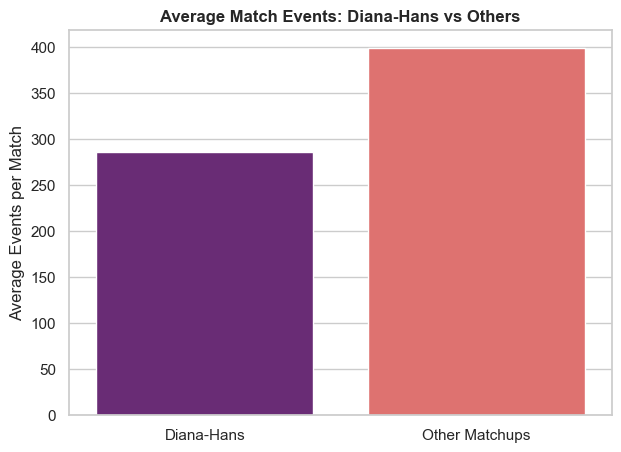

In [204]:
plt.figure(figsize=(7, 5))
sns.barplot(x=["Diana-Hans", "Other Matchups"], y=[dh_counts.mean(), other_counts.mean()], hue=["Diana-Hans", "Other Matchups"], palette="magma")
plt.title("Average Match Events: Diana-Hans vs Others", fontweight="bold")
plt.ylabel("Average Events per Match")
plt.show()

### 4.5.2 Hypotheses

#### Hypothesis 24: Magnus wins more rounds against Hans than against anyone else

**H0:** Magnus does not win more rounds against Hans than against anyone else.

**H1:** Magnus wins more rounds against Hans than against anyone else.

We're using a right-tailed Z-test for proportions.

We define $p_{\text{Against Hans}}$ as the round win rate of Magnus when playing against Hans and $p_{\text{Against Others}}$ as the round win rate of Magnus when playing against the other players

$$H_0: p_{\text{Against Hans}} \le p_{\text{Against Others}}$$
$$H_1: p_{\text{Against Hans}} > p_{\text{Against Others}}$$

In [205]:
magnus_rounds = round_data[(round_data["player_1"] == "Magnus") | (round_data["player_2"] == "Magnus")].copy()
magnus_rounds["magnus_won"] = magnus_rounds["round_winner"] == "Magnus"
magnus_rounds["opponent"] = np.where(
    magnus_rounds["player_1"] == "Magnus",
    magnus_rounds["player_2"],
    magnus_rounds["player_1"]
)
# Split into groups
magnus_hans = magnus_rounds[magnus_rounds["opponent"] == "Hans"]
magnus_others = magnus_rounds[magnus_rounds["opponent"] != "Hans"]

# Count wins and total rounds
hans_wins = magnus_hans["magnus_won"].sum()
hans_total = len(magnus_hans)

others_wins = magnus_others["magnus_won"].sum()
others_total = len(magnus_others)

# Z-test (right-tailed: Magnus wins more against Hans)
z_stat, p_value = proportions_ztest([hans_wins, others_wins], [hans_total, others_total], alternative="larger")

print(f"Magnus vs Hans  : {hans_wins}/{hans_total} = {hans_wins/hans_total*100:.2f}%")
print(f"Magnus vs Others: {others_wins}/{others_total} = {others_wins/others_total*100:.2f}%")
print(f"p value: {p_value:.4f}")

Magnus vs Hans  : 50/85 = 58.82%
Magnus vs Others: 136/310 = 43.87%
p value: 0.0072


The p-value is below 0.001. There is strong evidence for rejecting the null hypothesis in favor of the alternative hypothesis. That means that Magnus wins statistically more rounds against Hans than against anyone else. 

#### Hypothesis 25: Games for Diana and Hans have fewer events than the games for the other matchups.

H0: There is no statistically significant difference in the number of events in games of Diana and Hans and the number of events in games of other matchups.

H1: Games of Diana and Hans have significantly fewer events than games of other matchups.

We're using a left-tailed Welch's t-test.

We define $\mu_{\text{Diana, Hans}}$ as the average number of events in games of Diana and Hans $\mu_{\text{Others}}$ as the average number of events in games of other matchups.

$$H_0: \mu_{\text{Diana, Hans}} \ge \mu_{\text{Others}}$$
$$H_1: \mu_{\text{Diana, Hans}} < \mu_{\text{Others}}$$

In [206]:
t_stat, p_val = stats.ttest_ind(dh_counts, other_counts, equal_var=False, alternative='less')

print(f"Diana-Hans Avg Events/Game: {dh_counts.mean():.1f} (n={len(dh_counts)})")
print(f"Other Matchups Avg Events/Game: {other_counts.mean():.1f} (n={len(other_counts)})")
print(f"Welch's T-Statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


Diana-Hans Avg Events/Game: 285.6 (n=5)
Other Matchups Avg Events/Game: 398.7 (n=70)
Welch's T-Statistic: -2.6557, p-value: 0.0224


Statistical Results: With a p-value of 0.022, the results are not statistically significant after alpha adjustment.

Therefore, we cannot reject the null hypothesis even though there is a strong tendency of the game between Diana and Hans to have more events than the other games.

----------------------------